In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model_ranking.utils import (
    load_h5,
    get_roi_slice
)

INFO: P [MainThread] 2025-11-02 18:03:38,368 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
E_gt_path = "/scratch/talks/data/EPFL/test.h5"
E_gt = load_h5(E_gt_path, "labels")
E_raw = load_h5(E_gt_path, "raw")

In [3]:
path_HtoE_Resunet = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_full/Hm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
HtoE_pred = load_h5(path_HtoE_Resunet, "predictions")
patch_positions = load_h5(path_HtoE_Resunet, "patch_index")
f1_scores = load_h5(path_HtoE_Resunet, "hard_f1")

In [4]:
f1_scores[:, 1].max()

0.9735542

0.8338802

In [7]:
ids = np.where((f1_scores[:, 1] < 0.84) & (f1_scores[:, 1] > 0.83))[0]
print(len(ids))

28


In [9]:
ids[10]

433

(-0.5, 255.5, 255.5, -0.5)

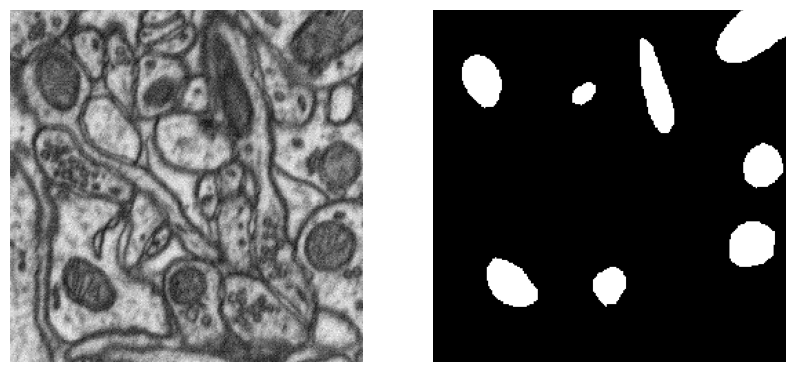

In [11]:
font_size = 20
idx = 433
# for i, idx in enumerate(ids[9:10]):
_ , axs = plt.subplots(1, 2, figsize=(10, 5))
patch_slice = get_roi_slice(patch_positions[idx])
axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
axs[0].axis('off')
axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
axs[1].axis('off')

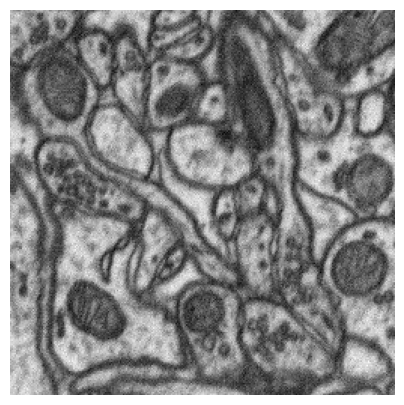

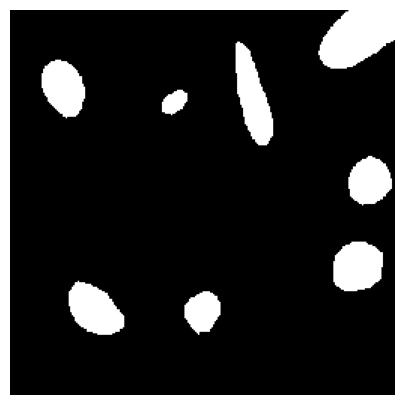

In [15]:
plt.figure(figsize=(5,5))
patch_slice = get_roi_slice(patch_positions[idx])
plt.imshow(E_raw[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/EPFL_raw.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.figure(figsize=(5,5))
plt.imshow(E_gt[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/EPFL_gt.png', bbox_inches='tight', pad_inches=0)
plt.show()

# Hm_model_Res1

In [56]:
path_HtoE_Resunet = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_full/Hm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
HtoE_pred = load_h5(path_HtoE_Resunet, "predictions")
patch_positions = load_h5(path_HtoE_Resunet, "patch_index")
f1_scores = load_h5(path_HtoE_Resunet, "hard_f1")

In [57]:
print(np.median(f1_scores[:, 1]))

0.8338802


0.83067375


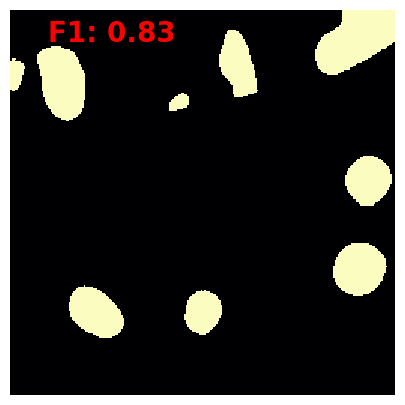

In [59]:
font_size = 20
for i, idx in enumerate([433]):
    fig, axs = plt.subplots(1, 1, figsize=(15, 5))
    print(f1_scores[idx, 1])
    patch_slice = get_roi_slice(patch_positions[idx])
    z, y, x = patch_positions[idx]
    axs.imshow(HtoE_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    #axs.set_title(f"F1: {f1_scores[idx, 1]:.2f}", fontsize=font_size)
    axs.axis('off')
    
    # Add F1 score as red text in lower right corner
    _ = axs.text(0.43, 0.90, f"F1: {f1_scores[idx, 1]:.2f}", 
             transform=axs.transAxes, fontsize=font_size, color='red',
             ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/HtoE_Res_Unet.png", bbox_inches='tight', pad_inches=0)
plt.show()

# E_model5

In [54]:
EtoE_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/consistency/P_full/E_model5/norm_Normalize/none/predictions/test_predictions.h5"
EtoE_pred = load_h5(EtoE_path, "predictions")
EtoE_patch_positions = load_h5(EtoE_path, "patch_index")
EtoE_f1_scores = load_h5(EtoE_path, "hard_f1")

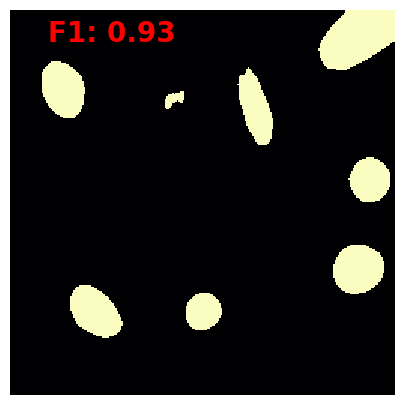

In [60]:
font_size = 20
for i, idx in enumerate([433]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    patch_slice = get_roi_slice(EtoE_patch_positions[idx])
    axs.imshow(EtoE_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    #axs.set_title(f"Prediction: F1: {EtoE_f1_scores[idx, 1]:.3f}, \n Source: EPFL, UNet", fontsize=font_size)
    axs.axis('off')

    # Add F1 score as red text in lower right corner
    _ = axs.text(0.43, 0.90, f"F1: {EtoE_f1_scores[idx, 1]:.2f}", 
             transform=axs.transAxes, fontsize=font_size, color='red',
             ha='right', va='bottom', fontweight='bold')
plt.show()

# Rm_model_NA2

In [44]:
RtoE_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_NA2/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_pred = load_h5(RtoE_path, "predictions")
RtoE_patch_positions = load_h5(RtoE_path, "patch_index")
RtoE_f1_scores = load_h5(RtoE_path, "hard_f1")

In [45]:
np.median(RtoE_f1_scores[:, 1])

0.10001396

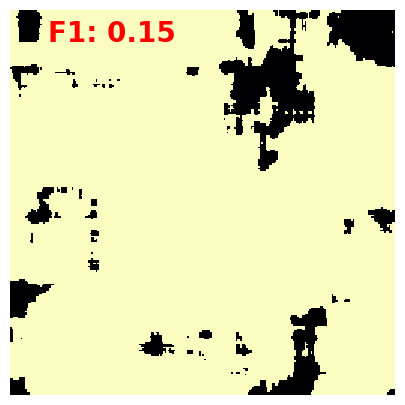

In [61]:
font_size = 20
for i, idx in enumerate([433]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_patch_positions[idx])
    axs.imshow(RtoE_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    #axs.set_title(f"F1: {RtoE_f1_scores[idx, 1]:.2f}", fontsize=font_size)
    axs.axis('off')

    # Add F1 score as red text in lower right corner
    _ = axs.text(0.43, 0.90, f"F1: {RtoE_f1_scores[idx, 1]:.2f}", 
             transform=axs.transAxes, fontsize=font_size, color='red',
             ha='right', va='bottom', fontweight='bold')
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/RtoE_NA_Unet.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Rm_model_Unetr2

In [27]:
RtoE_Unetr_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Unetr2/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_Unetr_pred = load_h5(RtoE_Unetr_path, "predictions")
RtoE_Unetr_patch_positions = load_h5(RtoE_Unetr_path, "patch_index")
RtoE_Unetr_f1_scores = load_h5(RtoE_Unetr_path, "hard_f1")

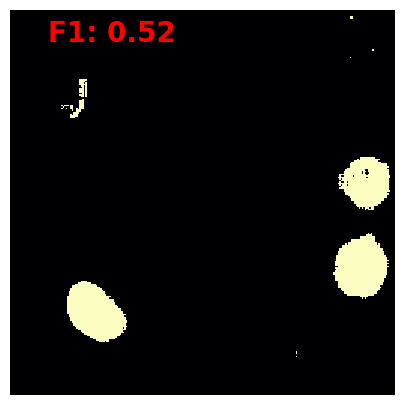

In [62]:
font_size = 20
for i, idx in enumerate([433]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_Unetr_patch_positions[idx])
    axs.imshow(RtoE_Unetr_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    #axs.set_title(f"F1: {RtoE_Unetr_f1_scores[idx, 1]:.2f}", fontsize=font_size)
    axs.axis('off')

    # Add F1 score as red text in lower right corner
    _ = axs.text(0.43, 0.90, f"F1: {RtoE_Unetr_f1_scores[idx, 1]:.2f}", 
             transform=axs.transAxes, fontsize=font_size, color='red',
             ha='right', va='bottom', fontweight='bold')
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/RtoE_Unetr.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Rmito

In [29]:
Rmito_gt_path = "/scratch/talks/data/Rmito/test_converted.h5"
Rmito_gt = load_h5(Rmito_gt_path, "labels")
Rmito_raw = load_h5(Rmito_gt_path, "raw")

In [54]:
Rmito_raw.shape

(150, 4096, 4096)

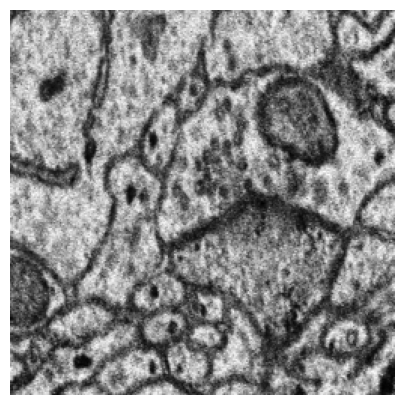

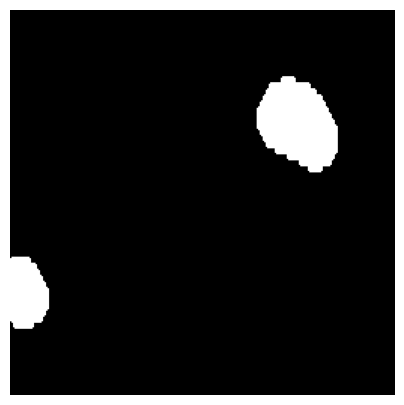

In [31]:
plt.figure(figsize=(5,5))
patch_slice = get_roi_slice(patch_positions[idx])
plt.imshow(Rmito_raw[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/Rmito_raw.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.figure(figsize=(5,5))
plt.imshow(Rmito_gt[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/Rmito_gt.png', bbox_inches='tight', pad_inches=0)
plt.show()

# Hmito GT

In [32]:
Hmito_gt_path = "/scratch/talks/data/Hmito/test_converted.h5"
Hmito_gt = load_h5(Hmito_gt_path, "labels")
Hmito_raw = load_h5(Hmito_gt_path, "raw")

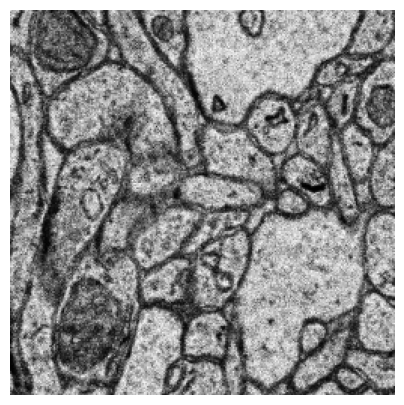

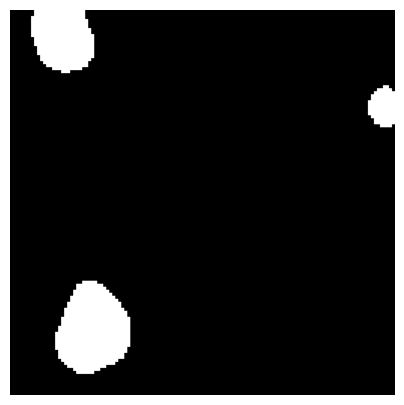

In [35]:
plt.figure(figsize=(5,5))
patch_slice = get_roi_slice(patch_positions[450])
plt.imshow(Hmito_raw[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/Hmito_raw.png', bbox_inches='tight', pad_inches=0)
plt.show()
plt.figure(figsize=(5,5))
plt.imshow(Hmito_gt[patch_slice].squeeze(), cmap="gray")
plt.axis('off')
plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/semantic_imgs/Hmito_gt.png', bbox_inches='tight', pad_inches=0)
plt.show()

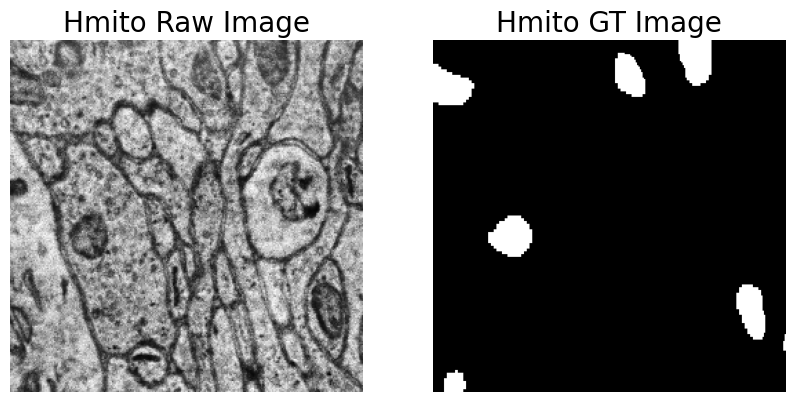

In [70]:

_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(Hmito_raw[0, 500:756, 500:756], cmap="gray")
axs[0].axis('off')
axs[0].set_title("Hmito Raw Image", fontsize=font_size)

axs[1].imshow(Hmito_gt[0, 500:756, 500:756], cmap="gray")
axs[1].axis('off')
axs[1].set_title("Hmito GT Image", fontsize=font_size)
plt.show()

In [4]:
RtoE_Res_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_Res_pred = load_h5(RtoE_Res_path, "predictions")
RtoE_Res_patch_positions = load_h5(RtoE_Res_path, "patch_index")
RtoE_Res_f1_scores = load_h5(RtoE_Res_path, "hard_f1")

In [7]:
RtoE_Res_f1_scores[:, 1].max()
ids = np.where((RtoE_Res_f1_scores[:, 1] >= 0.05) & (RtoE_Res_f1_scores[:, 1] < 0.06))[0]
print(len(ids))

38


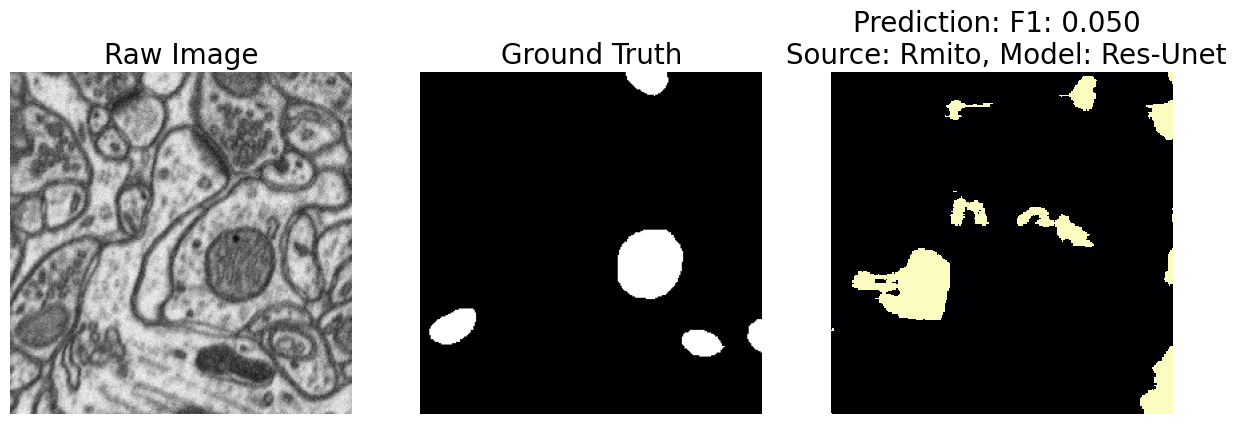

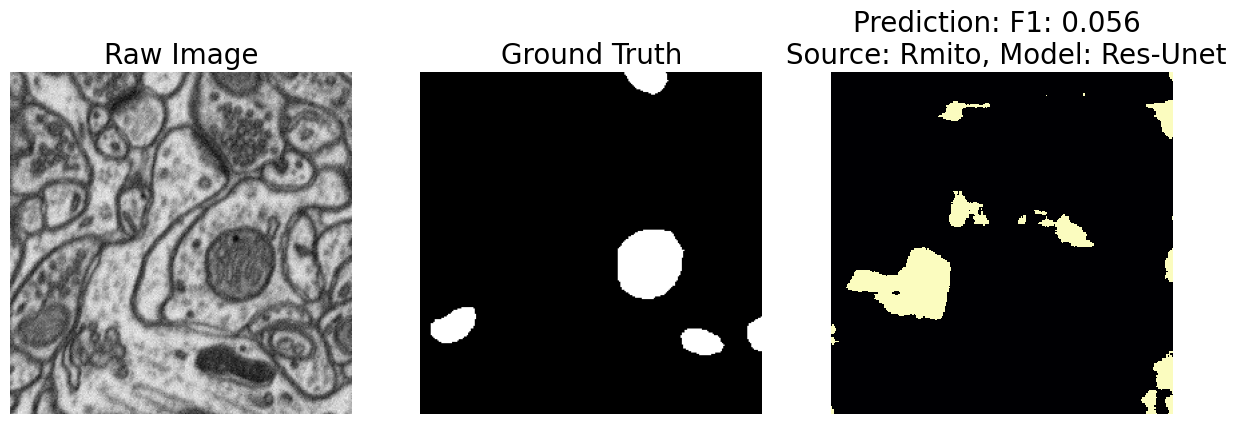

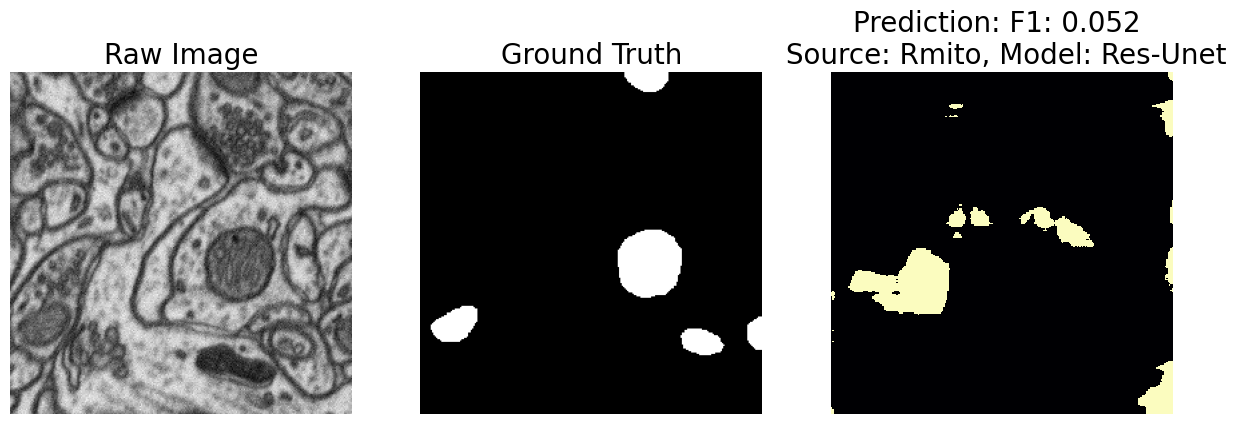

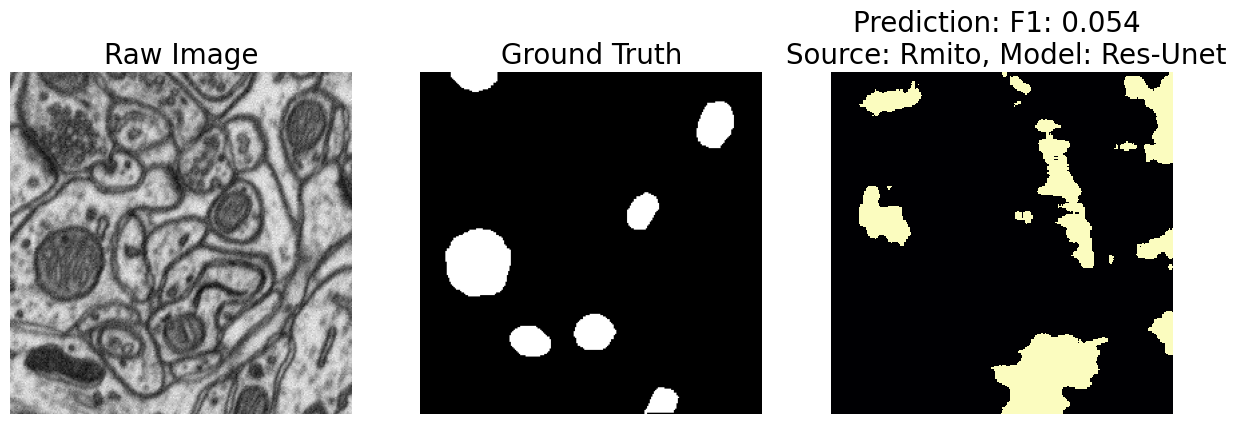

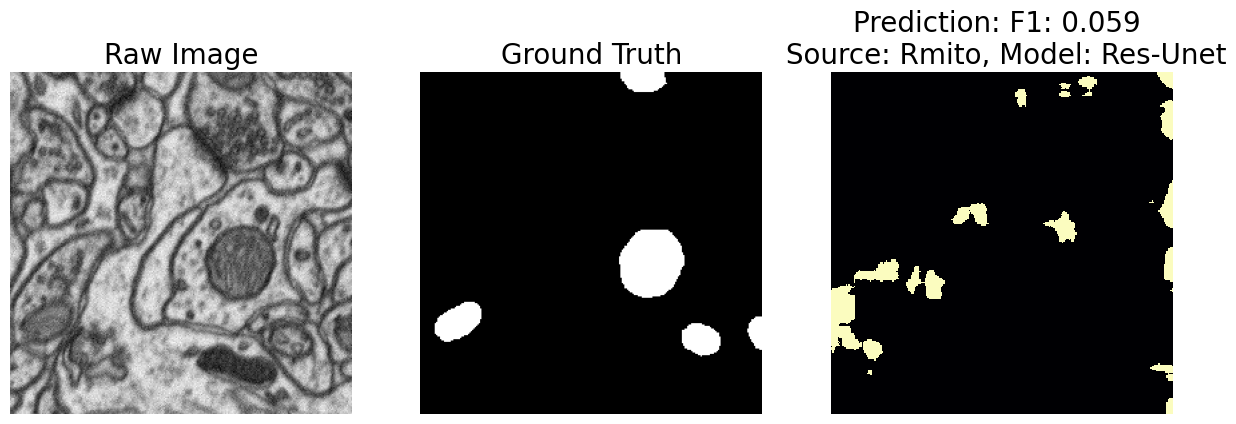

In [8]:
font_size = 20
for i, idx in enumerate(ids[:5]):
    _ , axs = plt.subplots(1, 3, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_Res_patch_positions[idx])
    axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    axs[0].set_title(f"Raw Image", fontsize=font_size)
    axs[0].axis('off')
    axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    axs[1].set_title(f"Ground Truth", fontsize=font_size)
    axs[1].axis('off')
    axs[2].imshow(RtoE_Res_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs[2].set_title(f"Prediction: F1: {RtoE_Res_f1_scores[idx, 1]:.3f} \n Source: Rmito, Model: Res-Unet", fontsize=font_size)
    axs[2].axis('off')
plt.show()